# 6.3 히스토그램

## 6.3.1 히스토그램 개념

히스토그램이란 어떤 데이터들이 얼마나 많은지를 도수(빈도수) 분포표를 그래프로 그린 것이다.
이는 화소의 분포를 나타내는 지표이므로 분포를 알면 영상의 특성을 판단할 도구가 될 수 있다.

## 6.3.2 히스토그램 게산
화소 값을 화소값이 가질 수 있는 범위에 대하여 빈도 수를 저장하면 된다. 그리고 이를 막대 그래프로 그린다.

In [1]:
import numpy as np, cv2
import matplotlib.pyplot as plt

In [ ]:
def calc_histo(img, histSize, ranges=[0,256]):
    hist = np.zeros((histSize, 1), np.float32)
    gap = ranges[1] / histSize

    for row in img:
        for pix in row:
            idx = int(pix / gap)
            hist[idx] += 1

    return hist

## 6.3.3 OpenCV 함수 활용
calcHist() 함수를 이용하면 다채녈의 행렬에서도 다차원의 히스토그램을 구할 수 있다.
https://docs.opencv.org/3.4/d6/dc7/group__imgproc__hist.html 

In [3]:
img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

histSize, ranges = [32], [0, 256]
gap = ranges[1] / histSize[0]
ranges_gap = np.arange(0, ranges[1] + 1, gap)
hist1 = calc_histo(img, histSize[0], ranges)
hist2 = cv2.calcHist([img], [0], None, histSize, ranges)
hist3, bins = np.histogram(img, ranges_gap)

print("User Func: ", hist1.flatten())
print("OpenCV Func: ", hist2.flatten())
print("numpy Func: ", hist3)

User Func:  [2.225200e+05 2.574840e+05 3.275370e+05 4.030800e+05 4.382150e+05
 4.064650e+05 3.772810e+05 5.260470e+05 8.442540e+05 7.842640e+05
 6.725010e+05 6.434450e+05 1.099683e+06 1.358913e+06 1.156761e+06
 9.675410e+05 8.386550e+05 8.991630e+05 9.638250e+05 9.826210e+05
 9.558970e+05 9.034380e+05 8.420320e+05 8.722470e+05 1.078317e+06
 9.696940e+05 7.423370e+05 6.679800e+05 9.304240e+05 1.727873e+06
 4.550640e+05 1.546500e+05]
OpenCV Func:  [2.225200e+05 2.574840e+05 3.275370e+05 4.030800e+05 4.382150e+05
 4.064650e+05 3.772810e+05 5.260470e+05 8.442540e+05 7.842640e+05
 6.725010e+05 6.434450e+05 1.099683e+06 1.358913e+06 1.156761e+06
 9.675410e+05 8.386550e+05 8.991630e+05 9.638250e+05 9.826210e+05
 9.558970e+05 9.034380e+05 8.420320e+05 8.722470e+05 1.078317e+06
 9.696940e+05 7.423370e+05 6.679800e+05 9.304240e+05 1.727873e+06
 4.550640e+05 1.546500e+05]
numpy Func:  [ 222520  257484  327537  403080  438215  406465  377281  526047  844254
  784264  672501  643445 1099683 1358913

In [4]:
def draw_histo(hist, shape=(200, 256)):
    hist_img = np.full(shape, 255, np.uint8)
    cv2.normalize(hist, hist, 0, shape[0], cv2.NORM_MINMAX)
    gap = hist_img.shape[1] / hist_img.shape[0]
    hist = hist.flatten()

    for i, h in enumerate(hist):
        x = int(round(i * gap))
        w = int(round(gap))
        cv2.rectangle(hist_img, (x, 0, w, int(h)), 0, cv2.FILLED)
    
    return cv2.flip(hist_img, 0)

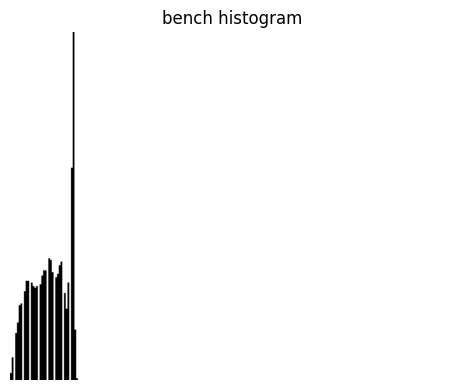

In [18]:
img = cv2.imread("../images/bench.jpg", cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([img], [0], None, [32], [0, 256])
hist_img = draw_histo(hist)

fig = plt.figure(num = 1, figsize=(8, 4))
plt.imshow(hist_img, cmap='gray')
plt.title("bench histogram")
plt.axis('off')
plt.tight_layout()

색상 히스토그램 그리기 6.4.4

In [ ]:
def make_palette(rows):
    hue = [round(i * 180 / rows) for i in range(rows)]
    

## 6.3.4 히스토그램 스트래칭
명암도 영상에서 영상이 선명하고 깨끗해 보이기 위해서 어두운 부분에서 밝은 부분이 고루 분포 되어야 함 하지만 고루 분포되어 있지 않으면 히스토그램의 분포가 좁아서 대비가 좋지 않다 그래서 히스토그램 스트래칭을 해주어 화질 개선을 꾀한다.

스트래칭을 하는 법은 대상이 되는 가장 낮거나 높은 화소값의 위치를 알아야 하고 낮은 값을 0으로 높은 값을 255로 당겨야 한다 그리고 중간에 있는 값들은 비율에 따라 화소값의 위치를 조정한다. 이를 수식으로 나타내면 (새 화소값) = (화소값 - LOW) * 255 / (HIGH - LOW) = (화소값 - LOW) / delta(x)

high_v:  252.0 low_v:  0.0


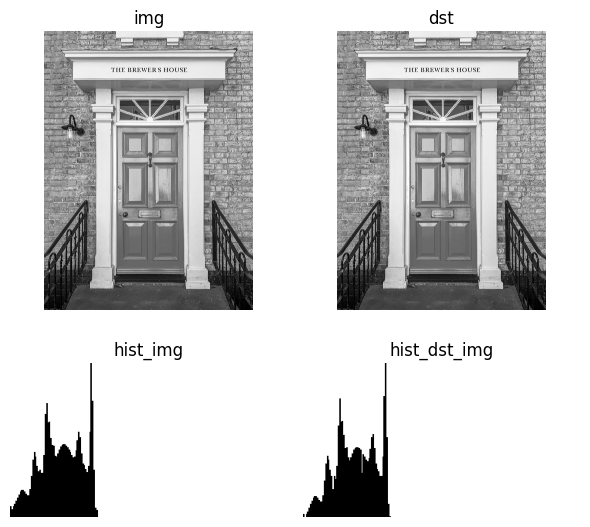

In [25]:
def search_value_idx(hist, bias = 0):
    for i in range(hist.shape[0]):
        idx = np.abs(bias - i)
        if hist[idx] > 0: return idx
    return -1

img = cv2.imread("../images/door.jpg", cv2.IMREAD_GRAYSCALE)

bsize, ranges = [64], [0, 256]
hist = cv2.calcHist([img], [0], None, bsize, ranges)

bin_width = ranges[1]/bsize[0]
low = search_value_idx(hist, 0) * bin_width
high = search_value_idx(hist, bsize[0] - 1) * bin_width

idx = np.arange(0, 256)
idx = (idx - low) / (high - low) * 255
idx[0:int(low)] = 0
idx[int(high+1):] = 255

dst = cv2.LUT(img, idx.astype('uint8'))

hist_dst = cv2.calcHist([dst], [0], None, bsize, ranges)
hist_img = draw_histo(hist, (200, 360))
hist_dst_img = draw_histo(hist_dst, (200, 360))

print("high_v: ", high, "low_v: ", low)

titles = ['img', 'dst', 'hist_img', 'hist_dst_img']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6, 6))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6.3.5 히스토그램 평활화
인간의 눈은 영상의 대비가 증가할 때 인지도가 향상된다. 그래서 평활화 알고리즘을 이용해서 분포의 균등을 이용해 명암 대비를 증가시켜 인지도 향상과 화질 개선을 할 수 있다.
히스토그램 스트래칭은 히스토그램의 분포가 좁은 영상을 스트레칭하여 히스토그램의 분포를 넓게 만들지만, 분포가 좁지는 않지만 특정 부분에서 한쪽으로 치우친 명암 분포를 가진 영상은 스트레칭으로 해결할 수 없다.
그래서 특정 부분에서만 한쪽으로 치우친 명암 분포를 가진 영상을 히스토그램의 재분배 과정을 거쳐 균등한 히스토그램 분포를 갖게 한다. 이를 히스토그램 평활화 라고 한다.

수행 과정은 아래와 같다.
1. 영상의 히스토그램을 계산한다.
2. 히스토그램 빈도값에서 누적 빈도수(누적합)를 계산한다. 
=> 이 과정은 어떤 화소 값에서 최소 화소 값까지의 합으로 알 수 있어 어떤 화소 값이 어디 위치에 있는지 알 수 있다. 예를 들어 같은 화소 값 200이라 해도 이미지와 누적 합에 따라 상위 1%가 될 수 있고 상위 10%가 될 수 있듯이 어떤 값의 순위를 알 수 있다.
3. 누적 빈도수를 정규화(정규화 누적합)한다.
4. 결과 화소값 = 정규화 누적합 * 최대 화소값

OpenCV의 함수 equalizeHist()를 이용한다. 설명은 위 6.3.3 링크 참고

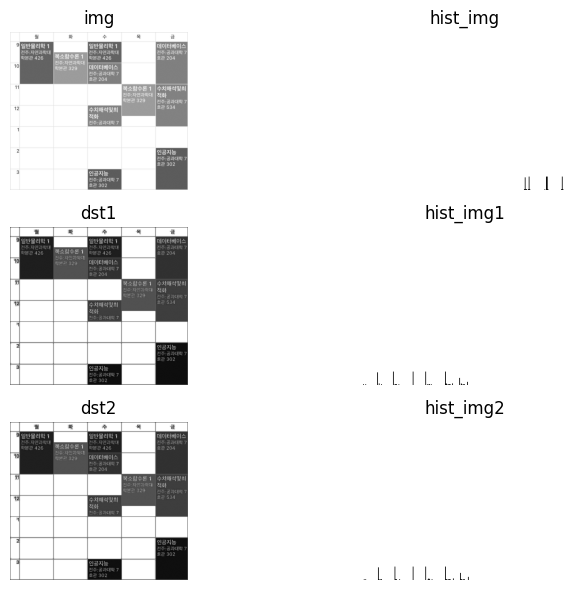

In [30]:
img = cv2.imread("../images/timetable.jpg", cv2.IMREAD_GRAYSCALE)

bsize, ranges = [256], [0, 256]
hist = cv2.calcHist([img], [0], None, bsize, ranges)

accum_hist = np.zeros(hist.shape[:2], np.float32)
accum_hist[0] = hist[0]
for i in range(1, hist.shape[0]):
    accum_hist[i] = accum_hist[i - 1] + hist[i]

accum_hist = (accum_hist / sum(hist)) * 255
dst1 = [[accum_hist[val] for val in row] for row in img]
dst1 = np.array(dst1, np.uint8)

dst2 = cv2.equalizeHist(img)
hist1 = cv2.calcHist([dst1], [0], None, bsize, ranges)
hist2 = cv2.calcHist([dst2], [0], None, bsize, ranges)

hist_img = draw_histo(hist)
hist_img1 = draw_histo(hist1)
hist_img2 = draw_histo(hist2)

titles = ['img', 'hist_img', 'dst1', 'hist_img1', 'dst2', 'hist_img2']

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(9, 6))

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()